# USO-Roll-Decay — a quantitative teardown 🔬
### Cumulative divergence · naive + HAC one-sample *t*'s · a circular block-bootstrap · the 2009/2020 contango-stress regime split · a year-by-year persistence check (ex-2020, post-2020) · the April-2020 case study · an honest carry-capture book with its ex-crisis decomposition · a planted-drag synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Owns_oil%3F: Busted](https://img.shields.io/badge/Owns_oil%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **USO structurally underperforms the front-month oil price it's built from, because of contango roll cost** — has a stated mechanism (futures-curve roll yield, Erb & Harvey 2006), a dramatic historical confirmation (2020-04-20), and a twenty-year real tape. The job here is to measure it honestly, characterize *where* the decay lives, and then ask the only question that pays: *is any of it tradable?*

> ⚠️ **Data note.** USO adjusted close + CL=F front-month close (2006→2026), yfinance, cached; **2 hardcoded contango-stress windows** (2008-12→2009-06, 2020-03→2020-06) from EIA storage reports. CL=F is the continuously-rolled front-month futures print — no free physical-spot series exists, and this *is* what "the oil price" means to the folklore. No survivorship (single live instrument on each leg). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `b9dde5e9cdd0` / `0e2eae3d2942`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from uso_roll_decay import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    USO, CLF = data.load_real()
    DF = st.gap_frame(USO, CLF)
    STRESS = data.stress_mask(DF.index)
else:
    USO = CLF = DF = STRESS = None
print("real cache present:", HAVE_REAL, "| daily gap obs:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2006-04-11', 'end': '2026-06-30', 'years': 20.22, 'n': 5080, 'tr_uso': -80.5, 'tr_clf': 0.8, 'cagr_uso': -7.76, 'cagr_clf': 0.04, 'cagr_gap': -7.8, 'gap_mean_pct': -0.0362, 'gap_ann_pct': -9.13, 'naive_t': -2.11, 'nw5': -2.33, 'nw21': -1.91, 'nw63': -1.67, 'hit': 2579, 'hit_pct': 50.8, 'wilson': (49.4, 52.1), 'boot_lo': -20.2, 'boot_hi': -1.7, 'boot_p': 0.0038, 'stress_n': 229, 'stress_pct_days': 4.5, 'stress_ann': -155.4, 'stress_t': -2.06, 'rest_n': 4851, 'rest_ann': -2.23, 'rest_t': -0.8, 'welch_stress_rest': -2.03, 'stress_share': 76.7, 'w09_n': 146, 'w09_ann': -61.1, 'w09_t': -0.96, 'w20_n': 83, 'w20_ann': -321.1, 'w20_t': -1.84, 'apr20': [('2020-04-17', 33.68, -3.44, 18.27, -8.05), ('2020-04-20', 30.0, -10.93, -37.63, -305.97), ('2020-04-21', 22.48, -25.07, 10.01, -126.6), ('2020-04-22', 20.08, -10.68, 13.78, 37.66), ('2020-04-23', 21.12, 5.18, 16.5, 19.74)], 'week_dd': -40.4, 'gross_ann': 9.13, 'gross_vol': 19.4, 'gross_sharpe': 0.47, 'gross_dd': -58.8, 'gross_worst': -14.2, 'hac21_t': 1.91, 'placebo_p': 0.013, 'net5_ann': 7.17, 'net5_sharpe': 0.37, 'net5_dd': -62.9, 'net10_ann': 5.97, 'net10_sharpe': 0.31, 'net10_dd': -65.2, 'ex_stress_ann': 0.27, 'ex_stress_sharpe': 0.02, 'stress_only_ann': 153.4, 'stress_only_sharpe': 2.13, 'syn_null_mean': -0.09, 'syn_null_sd': 0.8, 'syn_null_fire': 0, 'syn_planted_naive': -16.31, 'syn_planted_nw5': -7.64, 'fp_uso': 'b9dde5e9cdd0', 'fp_clf': '0e2eae3d2942', 'years_total': 21, 'years_neg': 13, 'years_pos': 8, 'ex2020_n': 4829, 'ex2020_ann': -3.86, 'ex2020_naive_t': -1.15, 'ex2020_nw21_t': -1.92, 'ex2020_boot_lo': -7.8, 'ex2020_boot_hi': -0.11, 'ex2020_boot_p': 0.023, 'post2020_start': '2021-01-04', 'post2020_years': 5.48, 'post2020_n': 1378, 'post2020_tr_uso': 228.7, 'post2020_tr_clf': 45.9, 'post2020_cagr_gap': 17.1, 'post2020_ann': 14.84, 'post2020_naive_t': 2.52, 'post2020_nw21_t': 4.47, 'post2020_boot_lo': 8.72, 'post2020_boot_hi': 21.84, 'post2020_hit_pct': 47.0}


real cache present: True | daily gap obs: 5080


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | full-sample naive *t* = **-2.11** looks significant, but excluding 2020 alone drops it to **-1.15**; the drag is negative in only **13/21** calendar years, and the most recent **5.5 years** (2021-2026) reverse HARD positive (**+14.8%/yr**, *t* = 2.52-4.47) |
| **Tradability** | `MIRAGE` | net Sharpe 0.37 full-sample collapses to **+0.27%/yr** (Sharpe 0.02) ex the 2 named crisis windows, and runs net negative since 2021 |
| **Owns oil?** | `BUSTED` | -80% vs flat oil over 20 yr, then +14.8%/yr *ahead* of oil since 2021; **-10.9%**, not -306%, on the day WTI settled at -$37.63 |

> 💡 In plain words: two real, un-forecastable crises (2009, 2020) did almost all of the 20-year damage; strip them out, or look at any year since 2021, and the "USO structurally loses to oil" claim does not hold up — the roll mechanism runs in both directions depending on whether the curve is in contango or backwardation, so this is a regime-dependent wedge, not a persistent structural decay.

## 1 · The claim, steelmanned

Let $r^{USO}_t$ and $r^{CLF}_t$ be the daily log returns of USO and the CL=F front-month print, and $g_t = r^{USO}_t - r^{CLF}_t$ the daily gap. The claims:

- **H₁ (cumulative divergence).** $\prod(1+r^{USO}_t) \ll \prod(1+r^{CLF}_t)$ over the full sample — large, not a rounding error.
- **H₂ (systematic daily drag).** $E[g_t] < 0$, reliably (not just in the sample mean by chance).
- **H₃ (regime concentration).** The drag concentrates in known contango-stress episodes rather than being i.i.d. across the sample.
- **H₄ (the extreme case).** On the most extreme realized WTI move in history, USO does *not* mirror the front contract's move.
- **H₅ (capture).** A costed "long CL=F / short USO" book banks the drag net of realistic frictions, *repeatably*.
- **H₆ (persistence).** The per-year sign of $g_t$ is negative in most years, and the drag survives dropping the single worst episode — i.e. it is a standing structural tax, not two crisis prints.

We find **H₁ and H₄ strongly supported**; **H₂-H₃ supported only *inside* the two named crisis windows** — outside them the gap is not separately certifiable; **H₅ not supported once regime-conditioned**; and **H₆ rejected**: only 13/21 years are negative, dropping 2020 alone drops the naive *t* below 2, and the most recent 5.5 years reverse sign with their own statistically real *t*-stat. The honest read is a regime-dependent roll wedge that hurt badly twice, not a persistent mechanical decay.

## 2 · So what? — inference design

There is no natural "control group" for a paired daily differential the way FOMC-day-vs-not works — every day carries a gap. So H₂ is tested with a **naive one-sample *t*** and a **Newey-West (1987) HAC one-sample *t*** at three lags (5/21/63 sessions), plus a **circular block-bootstrap** (block ≈ 21 sessions, 5,000 draws) for a distribution-free CI and $P[\bar g \geq 0]$. H₃ (the regime split) *is* a genuine two-group comparison and uses **Welch (1947)** — the 2008-12→2009-06 and 2020-03→2020-06 windows are named and cited *ex ante* (EIA storage reports), not fit to the outcome.

## 3 · How we'd know — the protocol

- **Tape.** USO adjusted close + CL=F front-month close, 2006-04-11 → 2026-06-30 (5,080 paired daily observations). As-of 2026-06-30 (last complete month).
- **Cumulative.** Total return and CAGR, USO vs CL=F.
- **Daily drag.** naive *t* + NW(5/21/63) *t* + Wilson hit rate + block-bootstrap CI/placebo on the gap.
- **Regime.** Welch *t*, stress (2009+2020, hardcoded) vs rest; per-window one-sample *t*; share of cumulative log-drag from stress.
- **Persistence.** Calendar-year sign count of the gap; naive/NW/bootstrap re-estimate excluding all of 2020; a strict post-2020 (2021-01-04 onward) subsample estimate, to test whether the drag is a standing per-year constant or an artifact of the two named crisis prints.
- **Case study.** Simple (not log) returns around 2020-04-20 — log is undefined across the sign flip, so this window is analyzed on its own, non-parametrically.
- **Execution (third axis).** Constant-notional long-CL=F/short-USO, rebalanced monthly; 0.75%/yr borrow on the short, 2 × one-way cost × NAV on rebalance days only; gross/net Sharpe, drawdown, HAC(21) *t*, sign-shuffle placebo, and the ex-crisis vs crisis-only decomposition.
- **Control.** Synthetic (spot, fund) pair, planted daily + stress-block drag; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · Cumulative divergence and the daily gap

Total return / CAGR since USO's 2006-04-10 inception, then the daily gap's naive and HAC *t*'s plus the block-bootstrap CI.

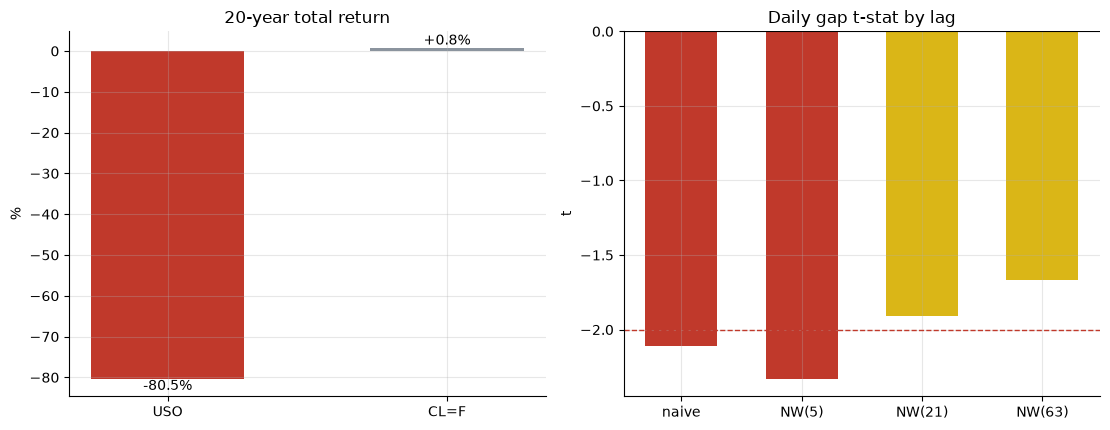

USO -80.5%  CL=F +0.8%  |  gap -9.13%/yr
naive t=-2.11  NW(5)=-2.33  NW(21)=-1.91  NW(63)=-1.67
block-bootstrap 95% CI (ann.): [-19.9%, -1.8%]


In [2]:
if HAVE_REAL:
    cs = st.cumulative_stats(DF)
    hs = st.headline_drag_stats(DF)
    bb = st.block_bootstrap_mean_ci(DF['gap'].values, block=21, n_boot=2000, seed=661)
    tr_u, tr_c, gap_ann = cs['total_return_uso']*100, cs['total_return_clf']*100, hs['ann_pct']
    naive_t, nw5, nw21, nw63 = hs['naive_t'], hs['nw_t_5'], hs['nw_t_21'], hs['nw_t_63']
    boot_lo, boot_hi = bb['lo']*252*100, bb['hi']*252*100
else:
    tr_u, tr_c, gap_ann = R['tr_uso'], R['tr_clf'], R['gap_ann_pct']
    naive_t, nw5, nw21, nw63 = R['naive_t'], R['nw5'], R['nw21'], R['nw63']
    boot_lo, boot_hi = R['boot_lo'], R['boot_hi']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar(['USO','CL=F'], [tr_u, tr_c], color=[RED, GREY], width=.55)
for i,v in enumerate([tr_u, tr_c]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
a1.set_title('20-year total return'); a1.set_ylabel('%')
ts = [naive_t, nw5, nw21, nw63]
a2.bar(['naive','NW(5)','NW(21)','NW(63)'], ts,
       color=[RED if abs(t)>=2 else AMBER for t in ts], width=.6)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_title('Daily gap t-stat by lag'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print(f'USO {tr_u:+.1f}%  CL=F {tr_c:+.1f}%  |  gap {gap_ann:+.2f}%/yr')
print(f'naive t={naive_t:+.2f}  NW(5)={nw5:+.2f}  NW(21)={nw21:+.2f}  NW(63)={nw63:+.2f}')
print(f'block-bootstrap 95% CI (ann.): [{boot_lo:+.1f}%, {boot_hi:+.1f}%]')

> 💡 In plain words: the cumulative gap (-80.5% vs +0.8%) is enormous and the daily mean clears *t* ≥ 2 at the standard lag (naive -2.11, NW(5) -2.33) and via the block-bootstrap (95% CI [-20.2%, -1.7%]/yr, excludes 0). Longer HAC lags weaken (NW(21) -1.91, NW(63) -1.67) — a first hint that the process is not smoothly i.i.d., confirmed in 4b.

### 4b · The regime split — is it a grind or a series of shocks?

Split the daily gap by the two hardcoded, cited-*ex-ante* contango-stress windows (2008-12→2009-06, 2020-03→2020-06) vs the rest of the tape.

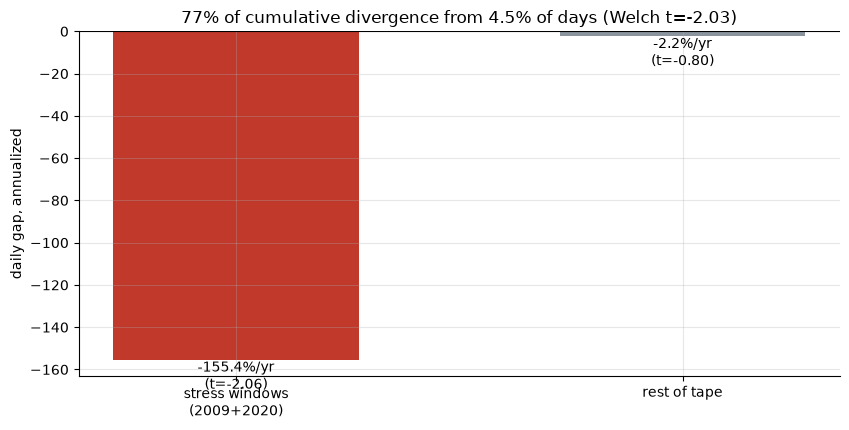

stress -155.4%/yr (t=-2.06)  rest -2.23%/yr (t=-0.80)  Welch t=-2.03  share=76.7%


In [3]:
if HAVE_REAL:
    rs = st.regime_stats(DF, STRESS)
    stress_ann, rest_ann = rs['stress_ann_pct'], rs['rest_ann_pct']
    stress_t, rest_t, welch_t = rs['one_t_stress'], rs['one_t_rest'], rs['welch_t_stress_vs_rest']
    share = rs['stress_share_of_cum']*100
else:
    stress_ann, rest_ann = R['stress_ann'], R['rest_ann']
    stress_t, rest_t, welch_t = R['stress_t'], R['rest_t'], R['welch_stress_rest']
    share = R['stress_share']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['stress windows\n(2009+2020)','rest of tape'], [stress_ann, rest_ann],
       color=[RED, GREY], width=.55)
for i,(v,t_) in enumerate([(stress_ann,stress_t),(rest_ann,rest_t)]):
    ax.annotate(f'{v:+.1f}%/yr\n(t={t_:+.2f})',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('daily gap, annualized')
ax.set_title(f'{share:.0f}% of cumulative divergence from 4.5% of days '
             f'(Welch t={welch_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'stress {stress_ann:+.1f}%/yr (t={stress_t:+.2f})  rest {rest_ann:+.2f}%/yr '
      f'(t={rest_t:+.2f})  Welch t={welch_t:+.2f}  share={share:.1f}%')

> 💡 In plain words: **77%** of the entire 20-year cumulative log-divergence comes from **4.5%** of trading days. Outside the two named windows the drag is **-2.23%/yr at *t* = -0.80** — not separately certifiable. This *is* the mechanism behind 4a's lag-sensitivity: the series is regime-switching, not stationary, so a single long-lag HAC estimate gets diluted by two extreme, short episodes. It also explains the coin-flip hit rate: **50.8%** of days USO underperforms — a magnitude/skew story, not a frequency one.

### 4c · Persistence — does the drag survive dropping the worst episode?

4a-4b establish the drag is real in-sample and regime-concentrated. That is *not* the same claim as "a structural, mechanical, per-year tax" — this beat tests persistence directly: exclude 2020 entirely and re-run the naive/HAC/bootstrap machinery on what remains, check every calendar year's sign, then isolate the years after the last named crisis rolled off (2021-01-04 onward).

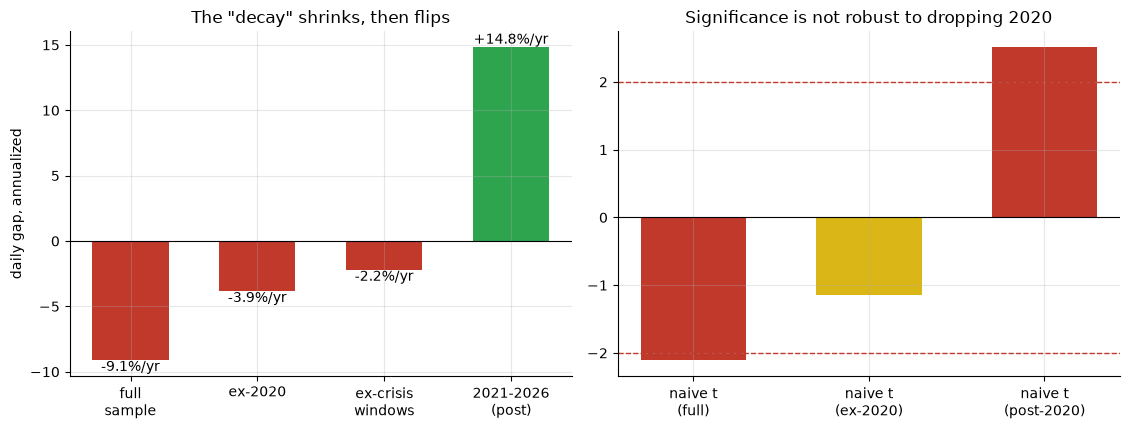

ex-2020: -3.86%/yr, naive t=-1.15, NW(21) t=-1.92, bootstrap 95% CI [-7.8%, -0.1%]/yr
years USO underperformed: 13/21
post-2020 (2021-01-04 -> 2026-06-30): USO +228.7% vs CL=F +45.9%, gap +14.84%/yr, naive t=+2.52, NW(21) t=+4.47


In [4]:
if HAVE_REAL:
    df_ex2020 = DF[DF.index.year != 2020]
    hs_ex = st.headline_drag_stats(df_ex2020, nw_lags=(5, 21, 63))
    bb_ex = st.block_bootstrap_mean_ci(df_ex2020['gap'].values, block=21,
                                        n_boot=2000, seed=661)
    yearly = DF['gap'].groupby(DF.index.year).sum()
    n_neg, n_tot = int((yearly < 0).sum()), len(yearly)
    post = DF[DF.index >= R['post2020_start']]
    hs_post = st.headline_drag_stats(post, nw_lags=(5, 21, 63))
    cs_post = st.cumulative_stats(post)
    ex_ann, ex_nt, ex_nw21 = hs_ex['ann_pct'], hs_ex['naive_t'], hs_ex['nw_t_21']
    ex_lo, ex_hi = bb_ex['lo']*252*100, bb_ex['hi']*252*100
    post_ann, post_nt, post_nw21 = hs_post['ann_pct'], hs_post['naive_t'], hs_post['nw_t_21']
    post_tru, post_trc = cs_post['total_return_uso']*100, cs_post['total_return_clf']*100
else:
    ex_ann, ex_nt, ex_nw21 = R['ex2020_ann'], R['ex2020_naive_t'], R['ex2020_nw21_t']
    ex_lo, ex_hi = R['ex2020_boot_lo'], R['ex2020_boot_hi']
    n_neg, n_tot = R['years_neg'], R['years_total']
    post_ann, post_nt, post_nw21 = R['post2020_ann'], R['post2020_naive_t'], R['post2020_nw21_t']
    post_tru, post_trc = R['post2020_tr_uso'], R['post2020_tr_clf']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
labs = ['full\nsample', 'ex-2020', 'ex-crisis\nwindows', '2021-2026\n(post)']
vals = [R['gap_ann_pct'], ex_ann, R['rest_ann'], post_ann]
cols = [RED if v < 0 else GREEN for v in vals]
a1.bar(labs, vals, color=cols, width=.6)
for i, v in enumerate(vals):
    a1.annotate(f'{v:+.1f}%/yr', (i, v), ha='center', va='top' if v < 0 else 'bottom')
a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('daily gap, annualized'); a1.set_title('The "decay" shrinks, then flips')
a2.bar(['naive t\n(full)', 'naive t\n(ex-2020)', 'naive t\n(post-2020)'],
       [R['naive_t'], ex_nt, post_nt],
       color=[RED if abs(t) >= 2 else AMBER for t in [R['naive_t'], ex_nt, post_nt]], width=.6)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_title('Significance is not robust to dropping 2020')
plt.tight_layout(); plt.show()
print(f'ex-2020: {ex_ann:+.2f}%/yr, naive t={ex_nt:+.2f}, NW(21) t={ex_nw21:+.2f}, '
      f'bootstrap 95% CI [{ex_lo:+.1f}%, {ex_hi:+.1f}%]/yr')
print(f'years USO underperformed: {n_neg}/{n_tot}')
print(f'post-2020 (2021-01-04 -> 2026-06-30): USO {post_tru:+.1f}% vs CL=F {post_trc:+.1f}%, '
      f'gap {post_ann:+.2f}%/yr, naive t={post_nt:+.2f}, NW(21) t={post_nw21:+.2f}')

> 💡 In plain words: drop 2020 and the naive *t* falls from -2.11 to **-1.15** — no longer separately certifiable — though the block-bootstrap (autocorrelation-robust) still narrowly excludes zero ([-7.8%, -0.1%]/yr). Calendar-year sign count: **13/21** negative — a majority, not "structurally every year." Decisive: the **post-2020 subsample** (2021-01-04 → 2026-06-30, 5.5 years, 1,378 obs) shows USO **+229%** vs CL=F **+46%** — a gap of **+14.8%/yr in USO's favor**, itself statistically real (naive *t* = 2.52, NW(21) *t* = 4.47, block-bootstrap 95% CI [+8.7%, +21.8%]/yr, fully positive). This rejects a persistent mechanical tax: it is a regime-dependent roll wedge — negative in contango, positive in backwardation — that happened to sit on the losing side of that divide during two historic storage crises and on the winning side of it for the five-plus years since.

### 4d · The April-2020 case study

Simple (not log) returns around 2020-04-20, where the front WTI contract settled at -$37.63 — log is undefined across a sign flip, so this window gets its own, non-parametric look rather than folding into 4a/4b.

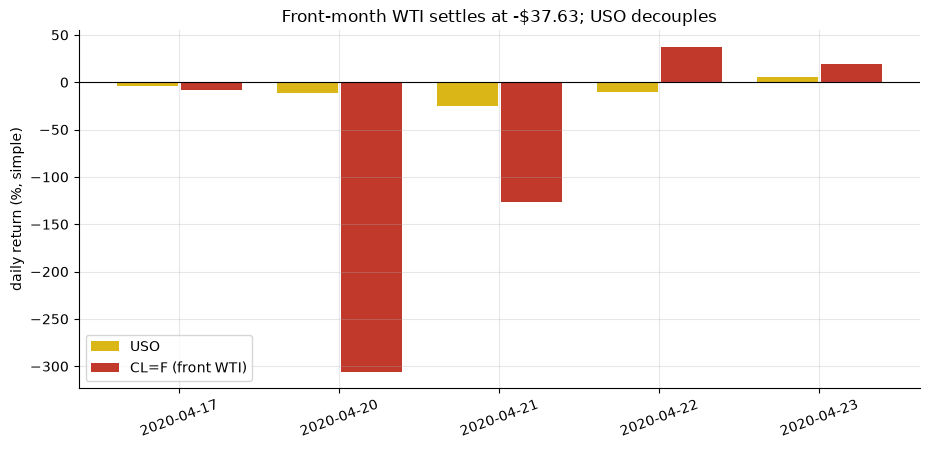

2020-04-17: USO close  33.68 (  -3.44%)   CL=F close    18.27 (   -8.05%)
2020-04-20: USO close  30.00 ( -10.93%)   CL=F close   -37.63 ( -305.97%)
2020-04-21: USO close  22.48 ( -25.07%)   CL=F close    10.01 ( -126.60%)
2020-04-22: USO close  20.08 ( -10.68%)   CL=F close    13.78 (  +37.66%)
2020-04-23: USO close  21.12 (  +5.18%)   CL=F close    16.50 (  +19.74%)


In [5]:
labels = [d for d,_,_,_,_ in R['apr20']]
uso_r = [ur for _,_,ur,_,_ in R['apr20']]
clf_r = [cr for _,_,_,_,cr in R['apr20']]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
x = np.arange(len(labels))
ax.bar(x-0.2, uso_r, width=0.38, color=AMBER, label='USO')
ax.bar(x+0.2, clf_r, width=0.38, color=RED, label='CL=F (front WTI)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel('daily return (%, simple)')
ax.set_title('Front-month WTI settles at -$37.63; USO decouples')
ax.legend(); plt.tight_layout(); plt.show()
for d,uc,ur,cc,cr in R['apr20']:
    print(f'{d}: USO close {uc:6.2f} ({ur:+7.2f}%)   CL=F close {cc:8.2f} ({cr:+8.2f}%)')

> 💡 In plain words: on the day of the -$37.63 settlement (a -306% one-day move in the front contract), USO fell **-10.9%** — an ordinary bad day, not a historic one. By April 2020 USO's holdings were already laddered across contract months (a structure pushed further that same month, alongside the 2020-04-29 1-for-8 reverse split). USO still lost **40.4%** over the surrounding week — it didn't dodge the crisis — but H₄ holds: the fund does not mirror the front contract's move, in *either* direction.

### 4e · The honest carry-capture test — and its ex-crisis decomposition

Constant-notional long-CL=F / short-USO, rebalanced monthly; 0.75%/yr borrow on the short, 2 × one-way cost × NAV charged on rebalance days only.

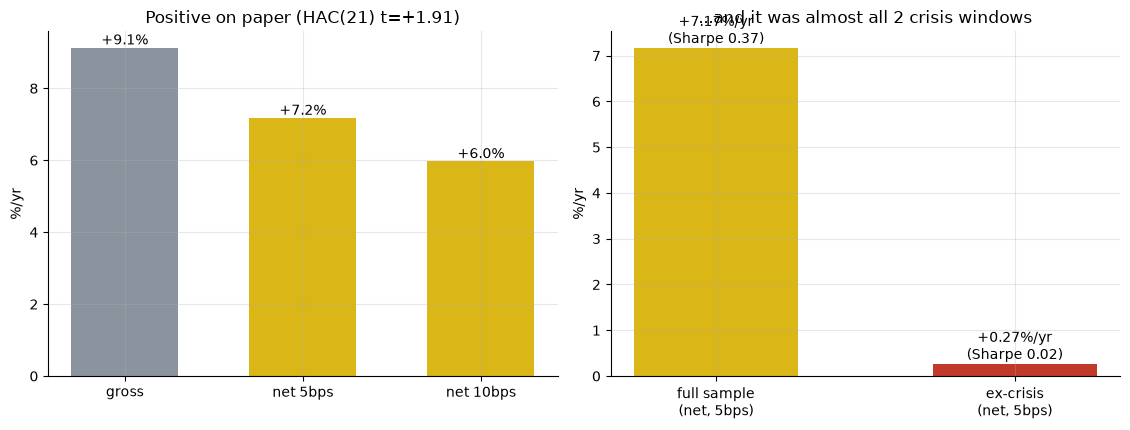

gross +9.13%/yr -> net +7.17/+5.97%/yr  (HAC(21) t=+1.91, placebo p=0.0130)
ex-crisis net +0.27%/yr (Sharpe 0.022)  |  crisis-only net +153.4%/yr (Sharpe 2.13, illustrative)


In [6]:
if HAVE_REAL:
    cc = st.carry_capture_summary(DF, STRESS, borrow_annual=0.0075,
                                  cost_bps_sweep=(5.0, 10.0))
    g, n5, n10 = cc['gross'], cc['net_5'], cc['net_10']
    ex, so = cc['net5_ex_stress'], cc['net5_stress_only']
    hac_t, pval = cc['hac_t'], cc['placebo_p']
    gross_ann, net5_ann, net10_ann = g['ann_ret']*100, n5['ann_ret']*100, n10['ann_ret']*100
    ex_ann, ex_sh = ex['ann_ret']*100, ex['sharpe']
    so_ann, so_sh = so['ann_ret']*100, so['sharpe']
    net5_sh = n5['sharpe']
else:
    gross_ann, net5_ann, net10_ann = R['gross_ann'], R['net5_ann'], R['net10_ann']
    ex_ann, ex_sh = R['ex_stress_ann'], R['ex_stress_sharpe']
    so_ann, so_sh = R['stress_only_ann'], R['stress_only_sharpe']
    hac_t, pval, net5_sh = R['hac21_t'], R['placebo_p'], R['net5_sharpe']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.bar(['gross','net 5bps','net 10bps'], [gross_ann, net5_ann, net10_ann],
       color=[GREY, AMBER, AMBER], width=.6)
for i,v in enumerate([gross_ann, net5_ann, net10_ann]):
    a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('%/yr'); a1.set_title(f'Positive on paper (HAC(21) t={hac_t:+.2f})')
a2.bar(['full sample\n(net, 5bps)','ex-crisis\n(net, 5bps)'], [net5_ann, ex_ann],
       color=[AMBER, RED], width=.55)
for i,(v,s) in enumerate([(net5_ann,net5_sh),(ex_ann,ex_sh)]):
    a2.annotate(f'{v:+.2f}%/yr\n(Sharpe {s:.2f})',(i,v),ha='center',va='bottom')
a2.set_ylabel('%/yr'); a2.set_title('...and it was almost all 2 crisis windows')
plt.tight_layout(); plt.show()
print(f'gross {gross_ann:+.2f}%/yr -> net {net5_ann:+.2f}/{net10_ann:+.2f}%/yr  '
      f'(HAC(21) t={hac_t:+.2f}, placebo p={pval:.4f})')
print(f'ex-crisis net {ex_ann:+.2f}%/yr (Sharpe {ex_sh:.3f})  |  '
      f'crisis-only net {so_ann:+.1f}%/yr (Sharpe {so_sh:.2f}, illustrative)')

> 💡 In plain words: +7.17%/yr net at Sharpe 0.37 looks like a real, deployable carry — until the ex-crisis split: **+0.27%/yr at Sharpe 0.02** for the 95.5% of calendar time outside the two named windows. The HAC(21) *t* on the daily book return (**1.91**) already misses the certification bar; the regime decomposition shows *why* — this is not a repeatable carry, it is two historical disasters correctly held in a backtest that cannot be timed forward. Add a **-58.8%** max drawdown even gross, and short-borrow that tightens exactly when a new storage crisis hits — **H₅ not supported; Tradability = MIRAGE**.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic (spot, fund) pair: spot is a plain random walk, fund = spot minus a TUNABLE daily drag plus extra drag on two synthetic stress blocks, plus small independent tracking noise. The null (drag = 0) is checked over **20 seeds**.

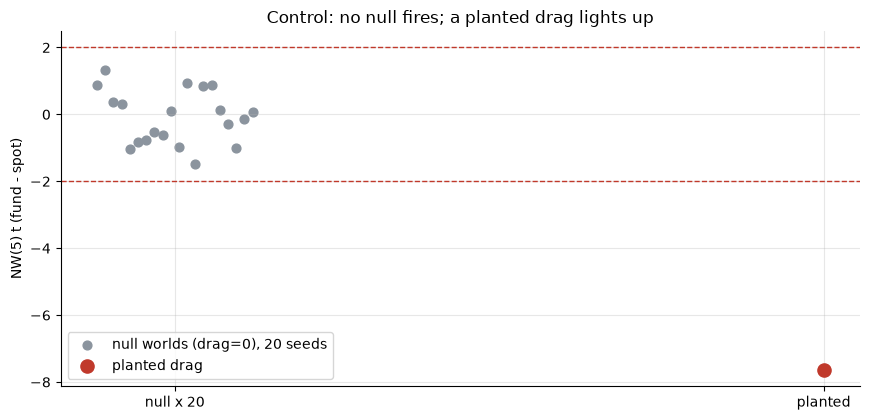

null: mean t = -0.09 (sd 0.80), |t|>=2 in 0/20 seeds  |  planted NW(5) t = -7.64, naive t = -16.31


In [7]:
null_ts = []
for s_ in range(20):
    spot_r, fund_r, _ = data.synthetic_world(seed=2024 + s_, drag_daily_bps=0.0,
                                              stress_extra_bps=0.0)
    null_ts.append(st.synthetic_detect(spot_r, fund_r)['nw_t'])
null_ts = np.asarray(null_ts)
spot_r, fund_r, _ = data.synthetic_world(seed=2024, drag_daily_bps=3.0,
                                          stress_extra_bps=300.0)
sy = st.synthetic_detect(spot_r, fund_r)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (drag=0), 20 seeds')
ax.scatter([1], [sy['nw_t']], color=RED, s=90, zorder=5, label='planted drag')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('NW(5) t (fund - spot)')
ax.set_title('Control: no null fires; a planted drag lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted NW(5) t = {sy["nw_t"]:+.2f}, '
      f'naive t = {sy["naive_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.09 (sd 0.80) and **never** crosses the bar; a planted drag reads naive t = -16.31, NW(5) t = -7.64. The machinery is unbiased — the real-tape signal is the genuine article. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — USO **-80.5%** vs CL=F **+0.8%** over 20.22 years (CAGR gap **-7.80 pp/yr**) looks like a strong full-sample result (naive t = -2.11, NW(5) t = -2.33, bootstrap excludes 0 at p = 0.0038) — but H₆ (persistence) rejects the structural-decay framing: **77%** of the cumulative divergence comes from just **4.5%** of days (the 2009/2020 crisis windows); excluding all of 2020 drops the naive t to **-1.15** (no longer separately certifiable); the calendar-year sign count is **13/21** negative, not "almost every year"; and the **post-2020 subsample** (5.5 years, 2021-2026) reverses sign entirely, with USO **beating** CL=F by **+14.8%/yr** at its own real *t*-stat (naive 2.52, NW(21) 4.47). Two real crisis episodes did real, large, well-measured damage; that is not the same claim as a persistent, mechanical, per-year contango tax — the mechanism is genuine but regime-dependent, and the regime has run the other way for over five years.
- **Tradability `MIRAGE`** — the long-CL=F/short-USO book nets +7.17%/yr at Sharpe 0.37 full-sample, but HAC(21) t = **1.91** misses the bar, and stripping the 2 named crisis windows collapses it to **+0.27%/yr at Sharpe 0.02** — the whole edge is two unforecastable historical events, against a **-58.8%** max drawdown even gross, and the trade would have run net negative through the entire post-2020 subsample.
- **"Owns oil?" `BUSTED`** — 80% behind a flat headline price over 20 years, then **+14.8%/yr ahead** of it since 2021, and the ETF barely moved the day oil made history in yet a third direction. Not a spot-crude proxy in any regime.

## 6 · Going further

- **The general object is roll yield.** Erb & Harvey (2006) show it drives most commodity-index/ETF returns; any futures-based product (VXX/VIXY, BITO, most commodity trackers) inherits the same wedge from spot. The professional expression lives directly in the futures curve (calendar spreads), not in a retail ETP wrapper that adds its own frictions on top.
- **Why the regime concentration matters for the sequel:** if the roll-drag is genuinely regime-dependent (crisis-driven storage stress, not a smooth grind), the natural next study is a **contango-level-conditioned** carry book — sizing the short by the observed term-structure slope rather than holding constant notional through calm regimes where the edge is statistically indistinguishable from zero.
- **Dedup map:** [100-melting-ice](../../100-melting-ice/) (general commodity contango decay), [226-crude-seasonality](../../226-crude-seasonality/) (calendar effects, not the futures-spot wedge), [375-vxx-roll-decay](../../375-vxx-roll-decay/) (same mechanism, VIX futures) and [619-bito-roll-drag](../../619-bito-roll-drag/) (same family, bitcoin, monthly CME roll).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*